In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import pulp
import random
import statistics
import time
from ortools.sat.python import cp_model

In [2]:
# Pulp modélise les problèmes linéaires, continues et entiers (CBC et CLP).
print(pulp.__version__)

4.0.0


In [3]:
prob = pulp.LpProblem("Production", pulp.LpMaximize)

tables = prob.add_variable("tables", 0, None, cat="Integer")
chaises = prob.add_variable("chaises", 0, None, cat="Integer")


# objet PuLP. Comme elle ne contient aucune comparaison (<=, >=, ==), PuLP la prend comme fonction objectif. 
# Elle sera maximisée, puisque le problème a été créé avec LpMaximize. 
# Le second élément, "Profit", est simplement le nom donné à cet objectif.
prob += 40 * tables + 30 * chaises, "Profit" 

# les contraintes
prob += 2 * tables + chaises <= 100, "Bois"
prob += tables + chaises <= 80, "Main_d_oeuvre"

stats = prob.solve(pulp.COIN_CMD(msg=False))
print("Problème :", prob)
print("Statut :", stats.status_str)
print("Tables :", pulp.value(tables))
print("Chaises :", pulp.value(chaises))
print("Profit :", pulp.value(prob.objective))

Problème : Production:
MAXIMIZE
30.0*chaises + 40.0*tables + 0.0
SUBJECT TO
Bois: chaises + 2 tables <= 100

Main_d_oeuvre: chaises + tables <= 80

VARIABLES
0 <= tables Integer
0 <= chaises Integer

Statut : Optimal
Tables : 20.0
Chaises : 60.0
Profit : 2600.0


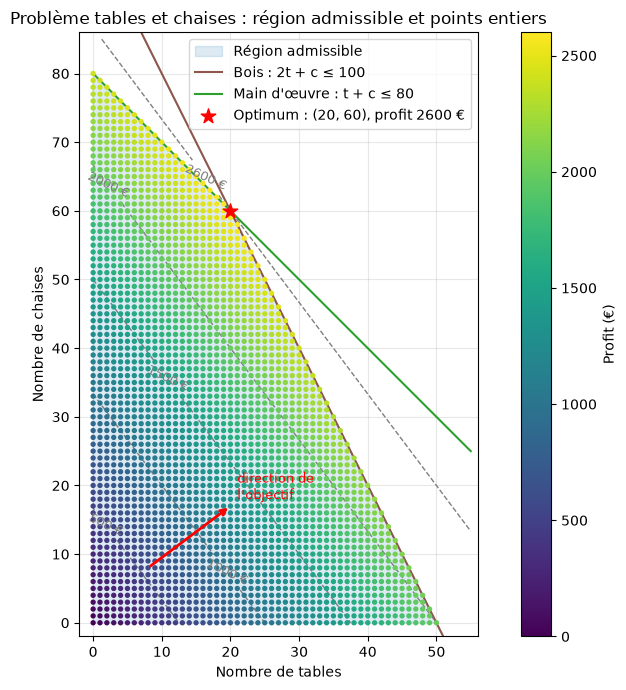

Points entiers admissibles : 2391
Meilleur point entier : 20 tables, 60 chaises, profit 2600


In [4]:
# Données du problème
profit_t, profit_c = 40, 30
def admissible(t, c):
    return (2 * t + c <= 100) & (t + c <= 80) & (t >= 0) & (c >= 0)

# Points entiers admissibles
T, C = np.meshgrid(np.arange(0, 51), np.arange(0, 81))
masque = admissible(T, C)
pts_t, pts_c = T[masque], C[masque]
profits = profit_t * pts_t + profit_c * pts_c

# Meilleur point entier (vérification)
i_opt = np.argmax(profits)
t_opt, c_opt, p_opt = pts_t[i_opt], pts_c[i_opt], profits[i_opt]

fig, ax = plt.subplots(figsize=(9, 7))

# Région admissible (polygone formé par les sommets)
sommets = np.array([(0, 0), (50, 0), (20, 60), (0, 80)])
ax.fill(sommets[:, 0], sommets[:, 1], alpha=0.15, color="tab:blue",
        label="Région admissible")

# Droites de contraintes
t_ligne = np.linspace(0, 55, 200)
ax.plot(t_ligne, 100 - 2 * t_ligne, color="tab:brown", label="Bois : 2t + c ≤ 100")
ax.plot(t_ligne, 80 - t_ligne, color="tab:green", label="Main d'œuvre : t + c ≤ 80")

# Lignes de niveau de la fonction objectif : 40t + 30c = constante
tt, cc = np.meshgrid(np.linspace(0, 55, 300), np.linspace(0, 85, 300))
niveaux = [500, 1000, 1500, 2000, 2600]
cs = ax.contour(tt, cc, profit_t * tt + profit_c * cc, levels=niveaux,
                colors="gray", linestyles="dashed", linewidths=1)
ax.clabel(cs, fmt="%d €", fontsize=9)

# Points entiers colorés selon le profit
sc = ax.scatter(pts_t, pts_c, c=profits, cmap="viridis", s=8, zorder=3)
fig.colorbar(sc, ax=ax, label="Profit (€)")

# Optimum
ax.scatter([t_opt], [c_opt], color="red", s=120, marker="*", zorder=5,
           label=f"Optimum : ({t_opt}, {c_opt}), profit {p_opt} €")

# Direction d'amélioration de l'objectif (gradient)
ax.annotate("", xy=(8 + 40 * 0.3, 8 + 30 * 0.3), xytext=(8, 8),
            arrowprops=dict(arrowstyle="->", color="red", lw=2))
ax.text(21, 18, "direction de\nl'objectif", color="red", fontsize=9)
ax.set_aspect("equal")
ax.set_xlim(-2, 56)
ax.set_ylim(-2, 86)
ax.set_xlabel("Nombre de tables")
ax.set_ylabel("Nombre de chaises")
ax.set_title("Problème tables et chaises : région admissible et points entiers")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.savefig("img/pointsAdmissibles.png")
plt.tight_layout()
plt.show()


print(f"Points entiers admissibles : {len(pts_t)}")
print(f"Meilleur point entier : {t_opt} tables, {c_opt} chaises, profit {p_opt}")